<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/Prediction_of_Shared_Bikes_demand_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*This assignment is a programming assignment wherein you have to build a multiple linear regression model for the prediction of demand for shared bikes.*

*A bike-sharing system is a service in which bikes are made available for shared use to individuals on a short term basis for a price or free. Many bike share systems allow people to borrow a bike from a "dock" which is usually computer-controlled wherein the user enters the payment information, and the system unlocks it. This bike can then be returned to another dock belonging to the same system.*

*A US bike-sharing provider BoomBikes has recently suffered considerable dips in their revenues due to the ongoing Corona pandemic. The company is finding it very difficult to sustain in the current market scenario. So, it has decided to come up with a mindful business plan to be able to accelerate its revenue as soon as the ongoing lockdown comes to an end, and the economy restores to a healthy state. *

*In such an attempt, BoomBikes aspires to understand the demand for shared bikes among the people after this ongoing quarantine situation ends across the nation due to Covid-19. They have planned this to prepare themselves to cater to the people's needs*

*once the situation gets better all around and stand out from other service providers and make huge profits*.

*They have contracted a consulting company to understand the factors on which the demand for these shared bikes depends. Specifically, they want to understand the factors affecting the demand for these shared bikes in the American market. The company wants to know:*

Which variables are significant in predicting the demand for shared bikes.
How well those variables describe the bike demands *italicized text*

*You are required to model the demand for shared bikes with the available independent variables. It will be used by the management to understand how exactly the demands vary with different features. They can accordingly manipulate the business strategy to meet the demand levels and meet the customer's expectations. Further, the model will be a good way for management to understand the demand dynamics of a new market. *



In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [6]:
df.shape

(730, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


#### 1. EDA - Null Analysis, Outlier Analysis, Dropping of unnecassary **columns**

Text(0.5, 1.0, 'registered')

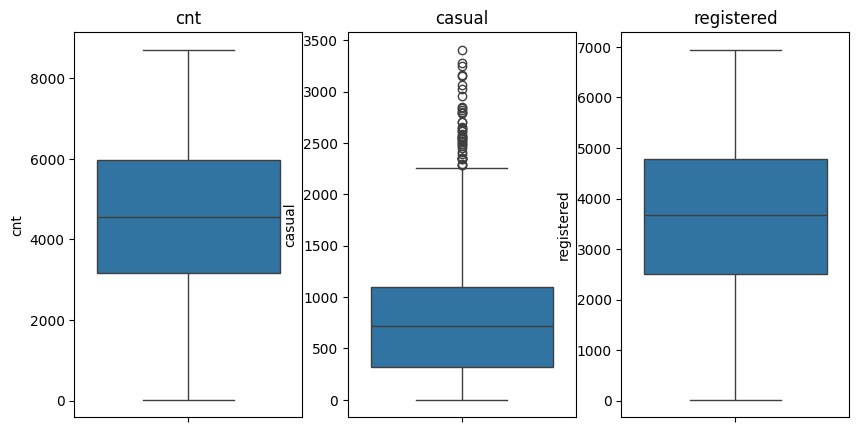

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
sns.boxplot(df['cnt'])
plt.title('cnt')

plt.subplot(1,3,2)
sns.boxplot(df['casual'])
plt.title('casual')

plt.subplot(1,3,3)
sns.boxplot(df['registered'])
plt.title('registered')


We are keeping outliers for registered .those can be real

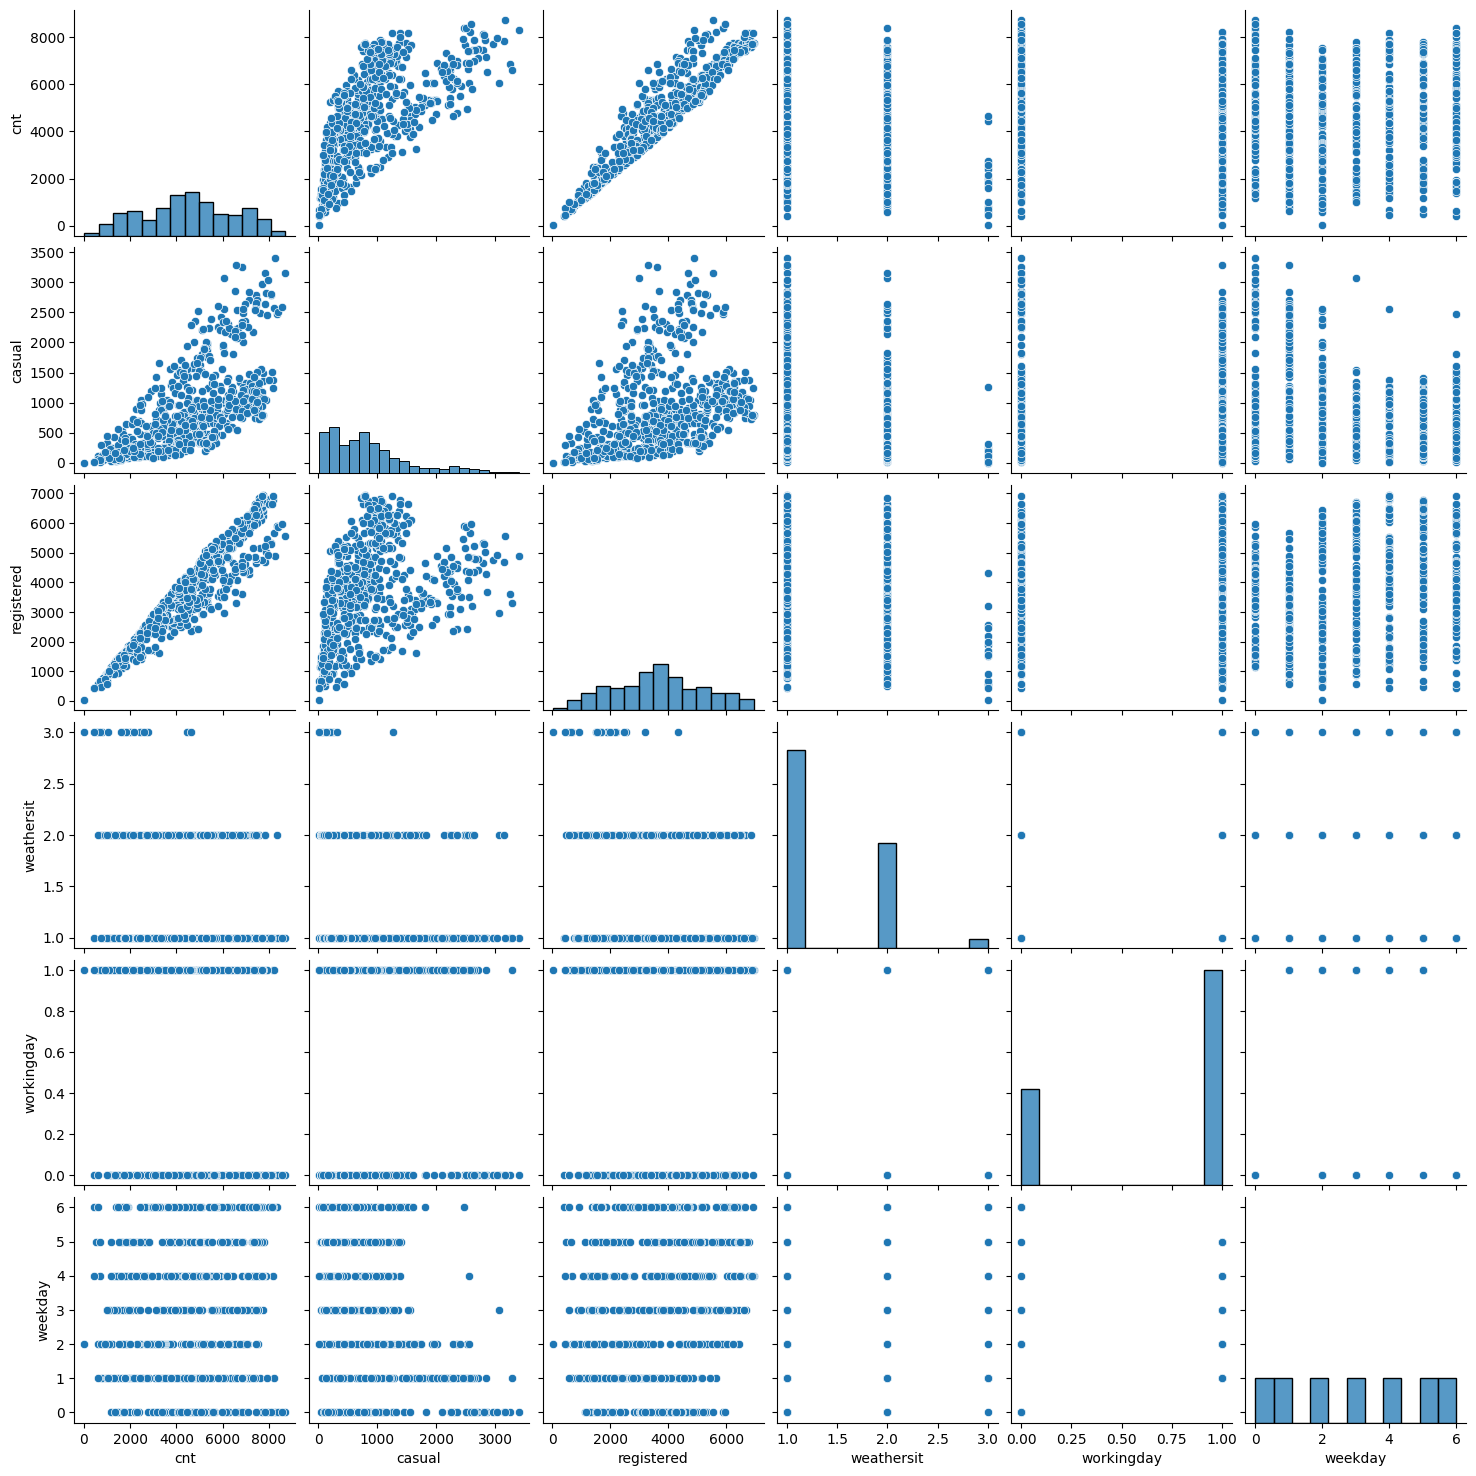

In [9]:
sns.pairplot(df[['cnt','casual','registered','weathersit','workingday','weekday']])

registered and casual attribute has linear relationship with cnt

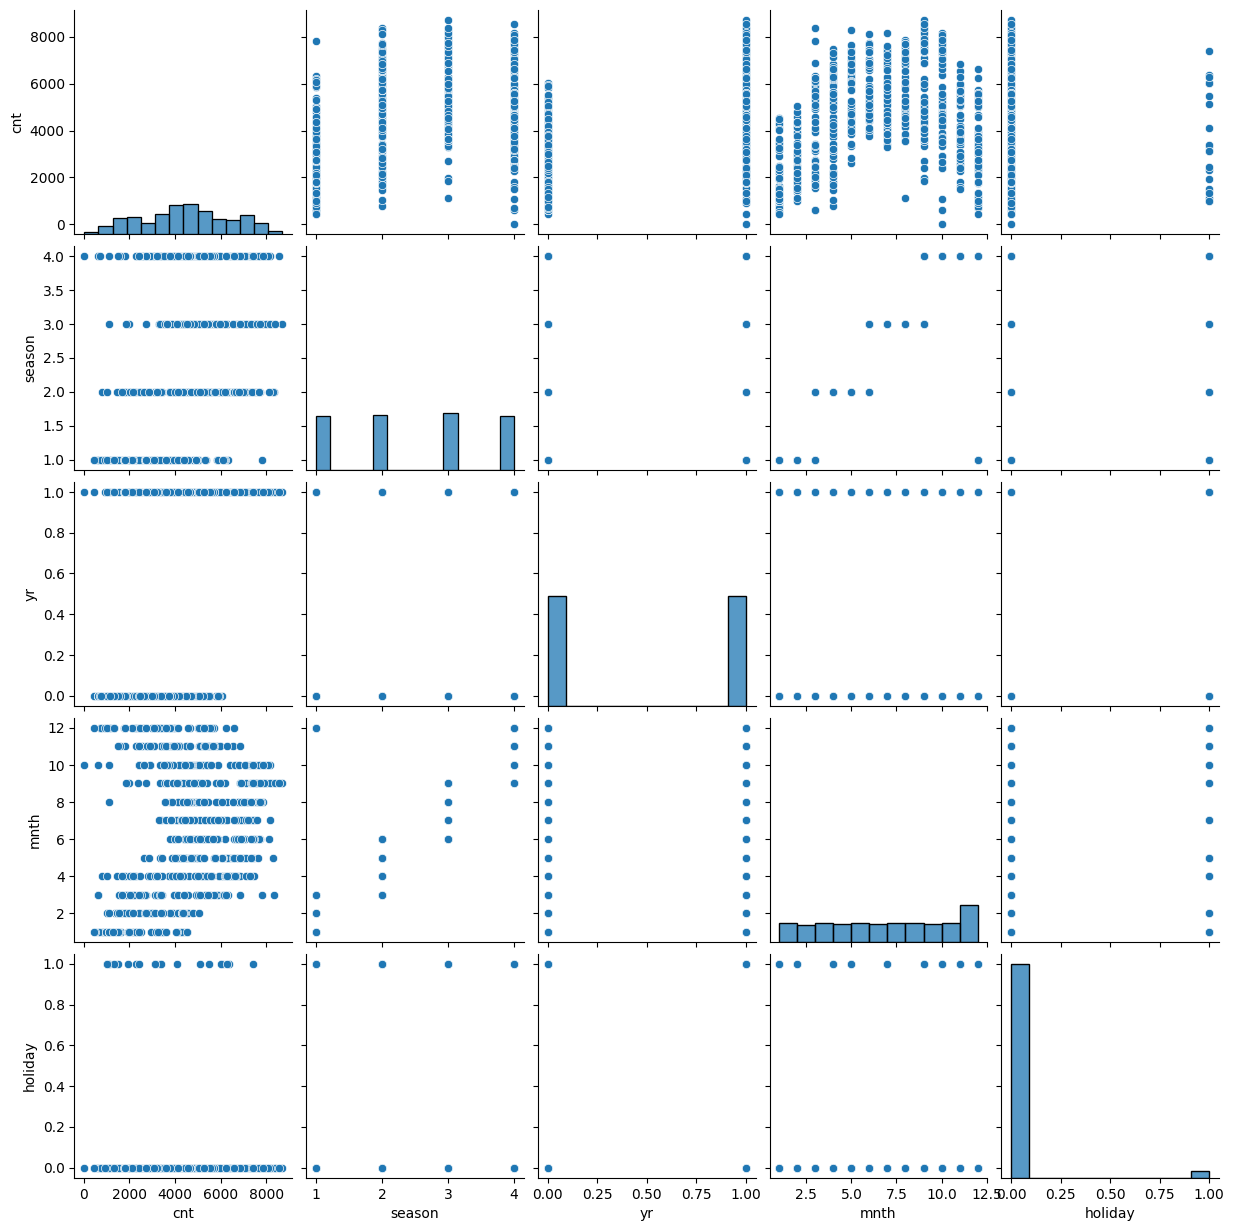

In [10]:
sns.pairplot(df[['cnt','dteday','season','yr','mnth','holiday']])

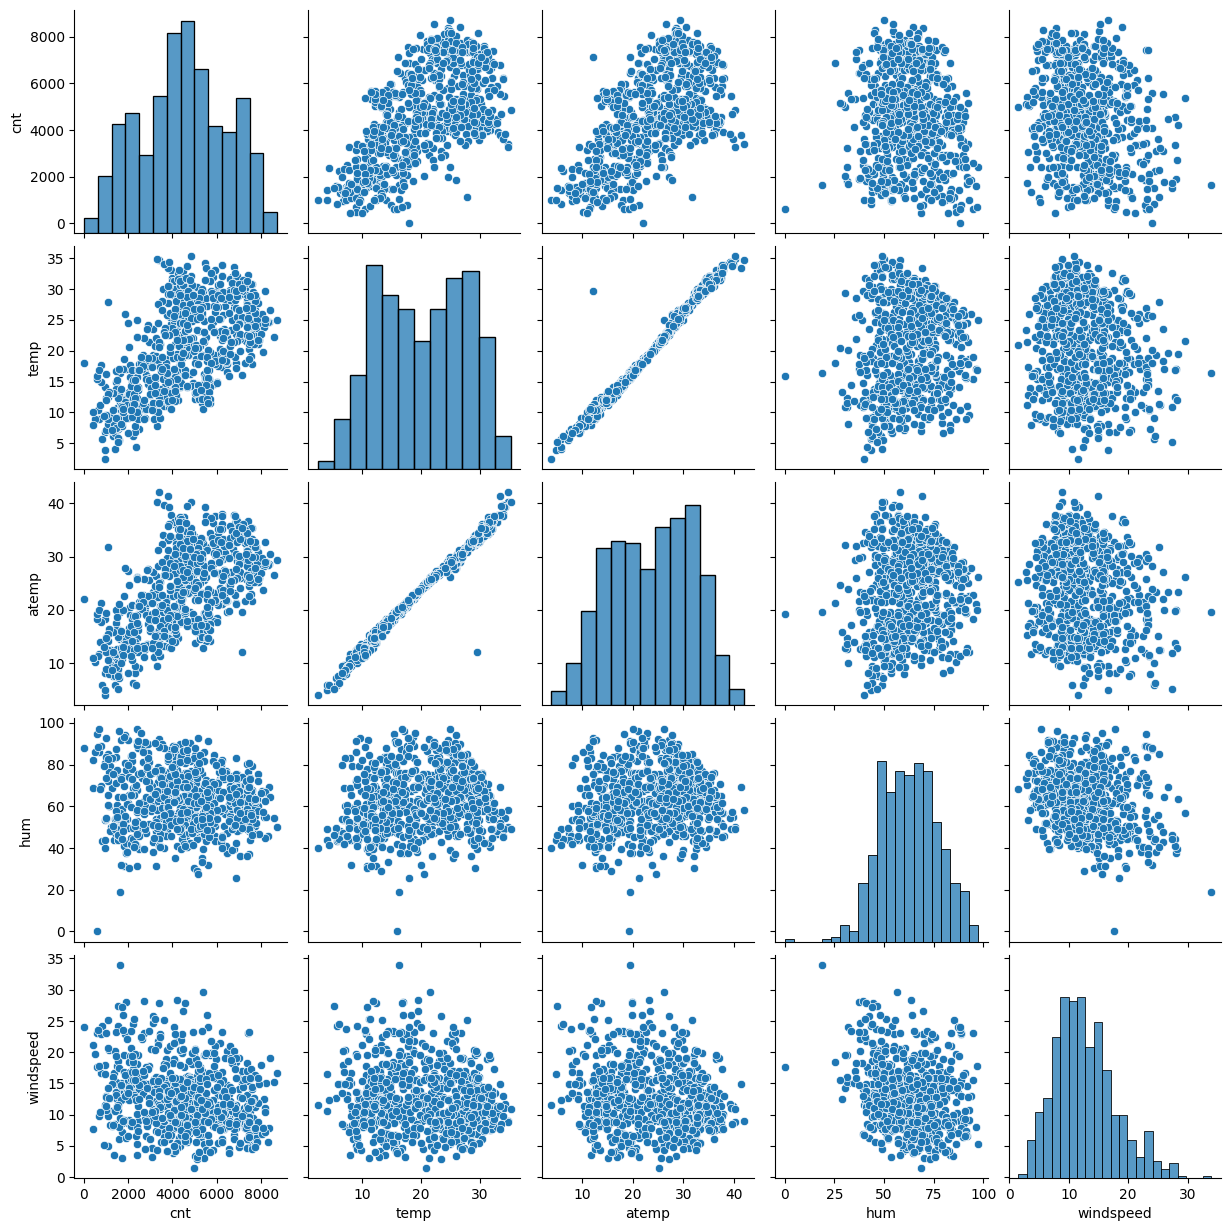

In [11]:
sns.pairplot(df[['cnt','temp','atemp','hum','windspeed']])

We see a linear relationship between cnt and (temp,atemp)
So, attributes that affect cnt is temp, atemp, casual, registered

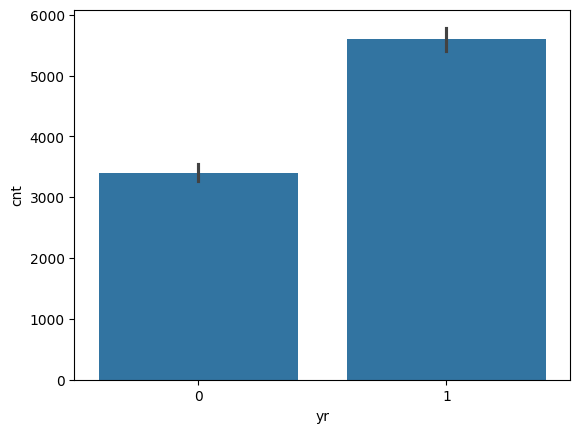

In [12]:

sns.barplot(x='yr',y='cnt', data=df)

plt.show()

We see , in 2019 , count has increased

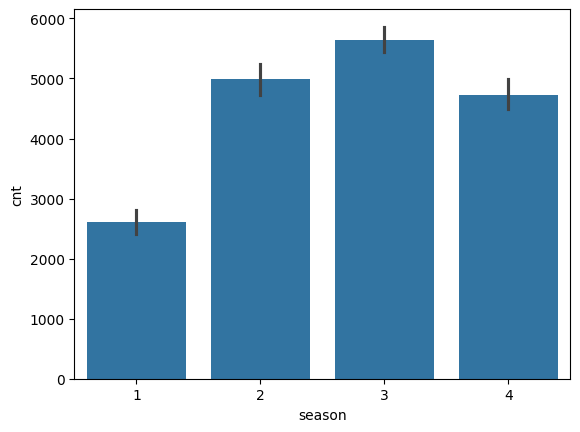

In [13]:
sns.barplot(x='season',y='cnt', data=df)

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split (df, train_size = 0.8, random_state = 101)


In [15]:
df_train.shape

(584, 16)

In [16]:
df_test.shape

(146, 16)

Feature Engineering - Scaling -- only for the attributes temp, atemp,hum,windspeed as those variables are varying , we need to scale it under 0 to 1

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical = ['temp','hum','windspeed','cnt']
df_train[numerical] = scaler.fit_transform(df_train[numerical])
df_train.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,363.037671,2.474315,0.503425,6.410959,0.027397,3.029110,0.693493,1.383562,0.543924,23.758492,0.559569,0.340796,846.558219,3651.681507,0.524580
std,210.861539,1.104811,0.500417,3.437102,0.163378,2.000217,0.461438,0.540126,0.229266,8.169160,0.180387,0.160739,687.686920,1548.200434,0.225580
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.953480,0.000000,0.000000,2.000000,20.000000,0.000000
25%,178.750000,1.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.346603,16.918900,0.423832,0.226924,317.000000,2497.500000,0.373784
50%,368.000000,2.000000,1.000000,6.000000,0.000000,3.000000,1.000000,1.000000,0.540519,23.973425,0.558573,0.315395,697.000000,3686.500000,0.530470
75%,543.250000,3.000000,1.000000,9.000000,0.000000,5.000000,1.000000,2.000000,0.744819,30.556150,0.691294,0.430268,1104.500000,4740.750000,0.688562
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,1.000000,42.044800,1.000000,1.000000,3410.000000,6946.000000,1.000000


In [18]:
print(df.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


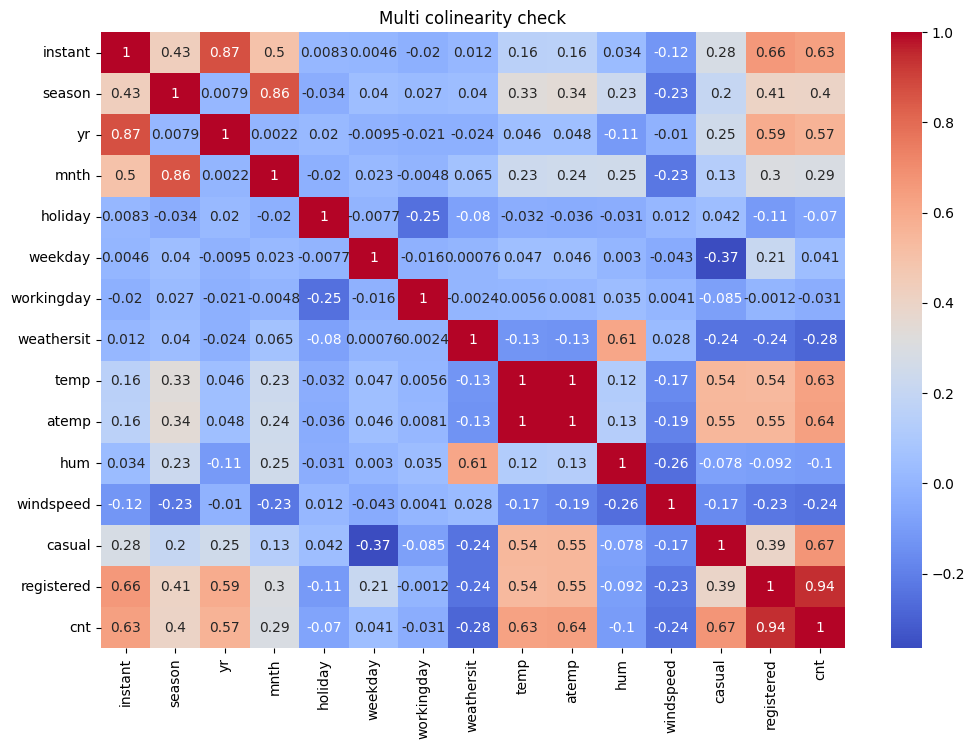

In [19]:
corr_matrix = df_train.drop('dteday', axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Multi colinearity check')
plt.show()

We can see from the heatmap that , season , year,temp,atemp,casual,registered have Collinearity  with cnt variable..so we ll remove casual and registered as count is actually casual+registered
We will remove atemp as temp is sifficient

We have to keep y train as cnt variable and rest other atrributes should be under x_train

In [20]:
y_train = df_train.pop('cnt')
df_train.drop(['dteday','atemp','casual','registered','instant','season','weathersit'], axis=1, inplace=True)
x_train = df_train

In [21]:
y_train.head()

,cnt
23,0.163366
527,0.580101
257,0.426228
18,0.190789
148,0.558537


In [22]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   yr          584 non-null    int64  
 1   mnth        584 non-null    int64  
 2   holiday     584 non-null    int64  
 3   weekday     584 non-null    int64  
 4   workingday  584 non-null    int64  
 5   temp        584 non-null    float64
 6   hum         584 non-null    float64
 7   windspeed   584 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 41.1 KB


In [27]:
x_train = x_train.apply(pd.to_numeric, errors = 'coerce')
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   yr          584 non-null    int64  
 1   mnth        584 non-null    int64  
 2   holiday     584 non-null    int64  
 3   weekday     584 non-null    int64  
 4   workingday  584 non-null    int64  
 5   temp        584 non-null    float64
 6   hum         584 non-null    float64
 7   windspeed   584 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 41.1 KB


In [28]:
y_train = y_train.apply(pd.to_numeric, errors = 'coerce')
y_train.info()

<class 'pandas.core.series.Series'>
Index: 584 entries, 23 to 523
Series name: cnt
Non-Null Count  Dtype  
--------------  -----  
584 non-null    float64
dtypes: float64(1)
memory usage: 9.1 KB


In [29]:
import statsmodels.api as sm
x_train.reset_index(drop = True)
y_train.reset_index(drop = True)

x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   yr          584 non-null    int64  
 1   mnth        584 non-null    int64  
 2   holiday     584 non-null    int64  
 3   weekday     584 non-null    int64  
 4   workingday  584 non-null    int64  
 5   temp        584 non-null    float64
 6   hum         584 non-null    float64
 7   windspeed   584 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 41.1 KB


In [30]:
x_train.columns

Index(['yr', 'mnth', 'holiday', 'weekday', 'workingday', 'temp', 'hum',
       'windspeed'],
      dtype='object')

In [31]:
x_train_sm = sm.add_constant(x_train,has_constant='add')

In [32]:
x_train_sm.columns


Index(['const', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'temp',
       'hum', 'windspeed'],
      dtype='object')

In [33]:
lr = sm.OLS(y_train, x_train_sm).fit()

In [34]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     229.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          2.42e-173
Time:                        14:33:54   Log-Likelihood:                 459.77
No. Observations:                 584   AIC:                            -901.5
Df Residuals:                     575   BIC:                            -862.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2600      0.027      9.711      0.0

*Cond no is high , do we need to recheck*

Find the multi colinearity using VIF

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train_sm.columns
vif['VIF'] = [variance_inflation_factor(x_train_sm.values, i) for i in range(x_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,34.00
2,mnth,1.14
7,hum,1.14
8,windspeed,1.12
6,temp,1.08
3,holiday,1.07
5,workingday,1.07
1,yr,1.02
4,weekday,1.00


In [36]:
y_train_pred  = lr.predict(x_train_sm)

<Axes: ylabel='Density'>

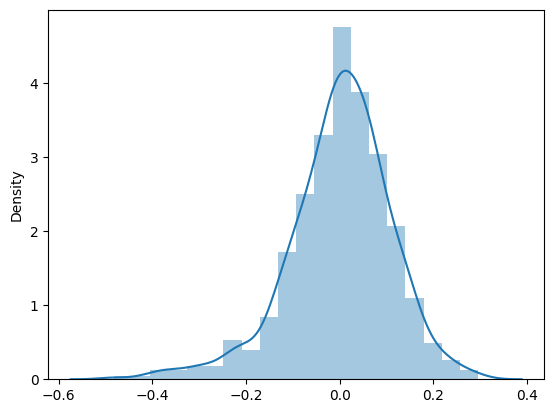

In [37]:
sns.distplot((y_train - y_train_pred), bins = 20)

Now we need to perform same test for test data that we created earlier and check if R2 is good

In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

numerical = ['temp','hum','windspeed','cnt']

df_test[numerical] = scaler.fit_transform(df_test[numerical])
df_test.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,375.349315,2.595890,0.486301,6.986301,0.034247,2.863014,0.678082,1.438356,0.501735,23.597639,0.653100,0.445099,860.013699,3687.061644,0.486136
std,211.376918,1.130021,0.501533,3.475999,0.182488,2.002172,0.468820,0.562906,0.261581,8.101098,0.151596,0.225013,683.878473,1610.295403,0.244938
min,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,6.313750,0.000000,0.000000,38.000000,491.000000,0.000000
25%,202.750000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.264831,16.247900,0.537168,0.285547,310.500000,2506.500000,0.303860
50%,361.500000,3.000000,0.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.538136,25.157200,0.651242,0.427697,773.000000,3595.000000,0.484092
75%,576.250000,4.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.721550,29.712087,0.755510,0.567453,1063.750000,4857.500000,0.691701
max,729.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,1.000000,41.318550,1.000000,1.000000,3160.000000,6911.000000,1.000000


In [45]:
y_test = df_test.pop('cnt')



KeyError: 'cnt'

In [46]:
df_test.drop(['dteday','atemp','casual','registered','instant','season','weathersit'], axis=1, inplace=True)
x_test = df_test

In [47]:
x_test.columns

Index(['yr', 'mnth', 'holiday', 'weekday', 'workingday', 'temp', 'hum',
       'windspeed'],
      dtype='object')

In [48]:
x_test=sm.add_constant(x_test)

In [49]:
y_test_pred = lr.predict(x_test)

<Axes: ylabel='Density'>

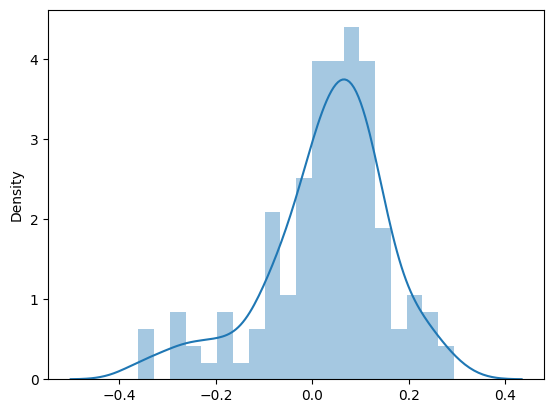

In [51]:
sns.distplot((y_test - y_test_pred),bins=20)

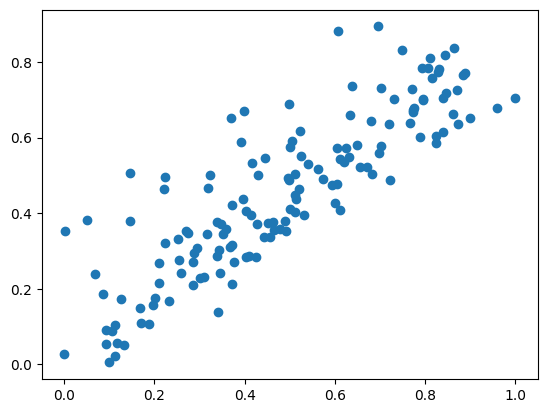

In [52]:
plt.scatter(y_test,y_test_pred)

In [53]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse

np.float64(0.12941959939065187)

In [54]:
r2_score(y_test, y_test_pred)

0.7188933427586612

We can see r2 score is more or less same for df_train and df_test dataset